###NHANES, here for Depression and Sleep, using Pingouin library for Chi square test of independence

In [2]:
import pandas as pd, pingouin as pg
nhanes=pd.read_csv("https://raw.githubusercontent.com/Psyc3000A/Data/refs/heads/main/nhanes.csv")
pg.chi2_independence(nhanes, x="HowOftenDoYouFeelDepressed", y="EverToldDoctorHadTroubleSleeping")


C:\Users\asohr\AppData\Local\Temp\ipykernel_22524\1674899589.py:2: DtypeWarning: Columns (141) have mixed types. Specify dtype option on import or set low_memory=False.
  nhanes=pd.read_csv("https://raw.githubusercontent.com/Psyc3000A/Data/refs/heads/main/nhanes.csv")


(EverToldDoctorHadTroubleSleeping          0.0         1.0
 HowOftenDoYouFeelDepressed                               
 0.0                               1866.324319  706.675681
 1.0                               1251.953274  474.046726
 2.0                                322.780537  122.219463
 3.0                                282.160964  106.839036
 4.0                                219.780905   83.219095,
 EverToldDoctorHadTroubleSleeping   0.0  1.0
 HowOftenDoYouFeelDepressed                 
 0.0                               2137  436
 1.0                               1236  490
 2.0                                264  181
 3.0                                199  190
 4.0                                107  196,
                  test    lambda        chi2  dof           pval    cramer  \
 0             pearson  1.000000  482.605128  4.0  3.872451e-103  0.240180   
 1        cressie-read  0.666667  470.001830  4.0  2.057373e-100  0.237023   
 2      log-likelihood  0.000000  45

### A hypothetical example of a 2 by 2 Chi squared (contingency) based on a 50 50 expectation model (each cell: 25 25 25 25) 

In [ ]:
import pandas as pd, pingouin as pg 
df = pd.DataFrame({
    "Sampled": ["Sampled"] * 50 + ["Not Sampled"] * 50,
    "Decision": (["Accept"] * 30 + ["Reject"] * 20 +
                 ["Accept"] * 10 + ["Reject"] * 40)})

pg.chi2_independence(data=df,x="Sampled",y="Decision")

(Decision     Accept  Reject
 Sampled                    
 Not Sampled    20.0    30.0
 Sampled        20.0    30.0,
 Decision     Accept  Reject
 Sampled                    
 Not Sampled    10.5    39.5
 Sampled        29.5    20.5,
                  test    lambda       chi2  dof      pval    cramer     power
 0             pearson  1.000000  15.041667  1.0  0.000105  0.387836  0.972470
 1        cressie-read  0.666667  15.144914  1.0  0.000100  0.389165  0.973301
 2      log-likelihood  0.000000  15.520812  1.0  0.000082  0.393965  0.976130
 3       freeman-tukey -0.500000  15.965481  1.0  0.000065  0.399568  0.979111
 4  mod-log-likelihood -1.000000  16.568113  1.0  0.000047  0.407039  0.982589
 5              neyman -2.000000  18.341809  1.0  0.000018  0.428273  0.989904)

### similar to the cell above but here with more details

In [126]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# Simple example
observed = pd.DataFrame(
    [[30, 20],
     [10, 40]],
    index=["Sampled", "Not Sampled"],columns=["Accept", "Reject"])

print("Observed Counts: \n",observed)

# Row/column/grand totals
print("\nObserved with Totals")
print(pd.crosstab(
    pd.Series(
        ["Sampled"] * 50 + ["Not Sampled"] * 50,
        name="Sampling"),
    pd.Series(
        ["Accept"] * 30 + ["Reject"] * 20 +
        ["Accept"] * 10 + ["Reject"] * 40,
        name="Decision"    ), margins=True))

# Expected counts
chi2, p, dof, expected = chi2_contingency(observed)

expected = pd.DataFrame(expected, index=observed.index, columns=observed.columns)

print("\nExpected Counts")
print(expected.round(2))

# Cell contributions
contributions = (observed - expected) ** 2 / expected

print("\nChi-square Contributions")
print(contributions.round(2))

# Standardized residuals
residuals = (observed - expected) / np.sqrt(expected)

print("\nStandardized Residuals")
print(residuals.round(2))

print("\nChi-square Statistic")
print(round(chi2, 2))

print("\nCheck:")
print("Sum of cell contributions =", round(contributions.to_numpy().sum(), 2))

Observed Counts: 
              Accept  Reject
Sampled          30      20
Not Sampled      10      40

Observed with Totals
Decision     Accept  Reject  All
Sampling                        
Not Sampled      10      40   50
Sampled          30      20   50
All              40      60  100

Expected Counts
             Accept  Reject
Sampled        20.0    30.0
Not Sampled    20.0    30.0

Chi-square Contributions
             Accept  Reject
Sampled         5.0    3.33
Not Sampled     5.0    3.33

Standardized Residuals
             Accept  Reject
Sampled        2.24   -1.83
Not Sampled   -2.24    1.83

Chi-square Statistic
15.04

Check:
Sum of cell contributions = 16.67


### Chi squared distribution at different DFs (left panel: 1-8, right panel: 8)

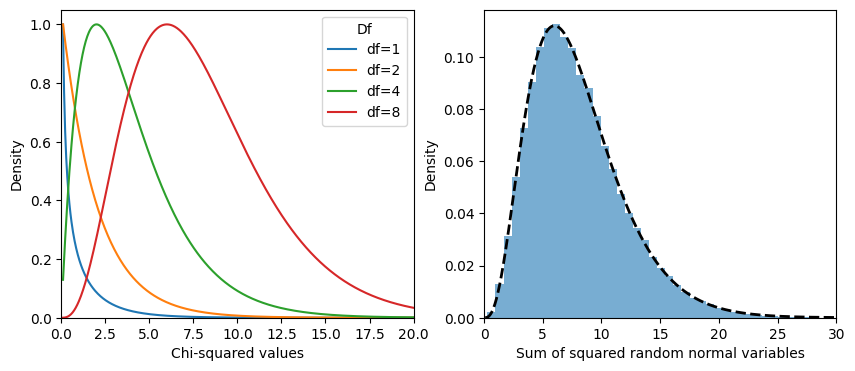

In [154]:
import numpy as np, matplotlib.pyplot as plt
from scipy.stats import chi2
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
x = np.linspace(0.1, 30, 1000)
for df in [1, 2, 4, 8]:
    y = chi2.pdf(x, df); y = y / y.max()
    ax[0].plot(x, y, label=f"df={df}")
z = np.random.normal(size=(50000, 8)) # Simulation
chi2_sim = (z**2).sum(axis=1)
ax[0].set_xlim(0, 20)
ax[0].set_ylim(0, 1.05)
ax[0].set_xlabel("Chi-squared values")
ax[0].set_ylabel("Density")
ax[0].legend(title="Df")
ax[1].hist(chi2_sim,bins=50,density=True,alpha=.6)
ax[1].plot(x,chi2.pdf(x, 8),"k--",lw=2)
ax[1].set_xlim(0, 30)
ax[1].set_xlabel("Sum of squared random normal variables")
ax[1].set_ylabel("Density")
plt.show()

###NHANES again, now using scipy not pg, here for Depression and Sleep, using Chi square test of independence, called chi2_contingency

In [35]:
import pandas as pd
from scipy.stats import chi2_contingency
import numpy as np
nhanes=pd.read_csv("https://raw.githubusercontent.com/Psyc3000A/Data/refs/heads/main/nhanes.csv")

table = pd.crosstab(nhanes['HowOftenDoYouFeelDepressed'],nhanes['EverToldDoctorHadTroubleSleeping'])

print(table)

chi2, p, dof, expected = chi2_contingency(table)

n = table.to_numpy().sum()
r, c = table.shape

cramers_v = np.sqrt(chi2 / (n * min(r-1, c-1)))

print(f"\nChi²({dof}) = {chi2:.3f} p = {p:.6g} Cramer's V = {cramers_v:.3f}")
expected_df = pd.DataFrame(expected,index=table.index,columns=table.columns)
residuals = (table - expected_df) / np.sqrt(expected_df)
print(residuals.round(2))

EverToldDoctorHadTroubleSleeping   0.0  1.0
HowOftenDoYouFeelDepressed                 
0.0                               2137  436
1.0                               1236  490
2.0                                264  181
3.0                                199  190
4.0                                107  196

Chi²(4) = 482.605 p = 3.87245e-103 Cramer's V = 0.298
EverToldDoctorHadTroubleSleeping   0.0    1.0
HowOftenDoYouFeelDepressed                   
0.0                               6.27 -10.18
1.0                              -0.45   0.73
2.0                              -3.27   5.32
3.0                              -4.95   8.05
4.0                              -7.61  12.36


C:\Users\asohr\AppData\Local\Temp\ipykernel_12012\2165471920.py:4: DtypeWarning: Columns (141) have mixed types. Specify dtype option on import or set low_memory=False.
  nhanes=pd.read_csv("https://raw.githubusercontent.com/Psyc3000A/Data/refs/heads/main/nhanes.csv")


### finally Police Data (see the Chapter and the powerpoint), again using Chi squared, round percents (first cell) and raw frequency and marginals (second cell) 

In [1]:
import pandas as pd
df=pd.read_csv(r"C:\Users\asohr\OneDrive - Carleton University\Aca\2026\Teach1234\3000\data\c4\yg821jf8611_az_statewide_2020_04_01.csv.zip")
pd.crosstab(df["subject_race"], df["search_conducted"],normalize="index").mul(100).round(2) #.astype(str) + '%'

C:\Users\asohr\AppData\Local\Temp\ipykernel_26816\2034425927.py:2: DtypeWarning: Columns (9,10,11,12,18,19,21,27,28) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv(r"C:\Users\asohr\OneDrive - Carleton University\Aca\2026\Teach1234\3000\data\c4\yg821jf8611_az_statewide_2020_04_01.csv.zip")


search_conducted,False,True
subject_race,,
asian/pacific islander,97.27,2.73
black,90.39,9.61
hispanic,91.27,8.73
other,89.83,10.17
unknown,95.08,4.92
white,95.81,4.19


In [2]:
pd.crosstab(df["subject_race"],df["search_conducted"],margins=True)

search_conducted,False,True,All
subject_race,,,
asian/pacific islander,82456,2311,84767
black,201309,21402,222711
hispanic,872698,83475,956173
other,150404,17025,167429
unknown,22463,1162,23625
white,1953954,85432,2039386
All,3283284,210807,3494091


In [5]:
# Counts
import pingouin as pg

# Chi-square
pg.chi2_independence(data=df,x="subject_race",y="search_conducted")




(search_conducted               False          True 
 subject_race                                       
 asian/pacific islander  7.965280e+04    5114.199078
 black                   2.092743e+05   13436.695775
 hispanic                8.984848e+05   57688.240407
 other                   1.573276e+05   10101.398390
 unknown                 2.219965e+04    1425.353654
 white                   1.916345e+06  123041.112696,
 search_conducted          False  True 
 subject_race                          
 asian/pacific islander    82456   2311
 black                    201309  21402
 hispanic                 872698  83475
 other                    150404  17025
 unknown                   22463   1162
 white                   1953954  85432,
                  test    lambda          chi2  dof  pval    cramer  power
 0             pearson  1.000000  36262.776138  5.0   0.0  0.101815    1.0
 1        cressie-read  0.666667  35759.139695  5.0   0.0  0.101105    1.0
 2      log-likelihood  0.000